# Figure 6 / Table S3 -- GWAS risk-variant analysis

Applies the fitted LogFC model to prostate cancer GWAS Catalog SNPs overlapping AR binding
site (ARBS) regions (Methods 2.8), and prioritizes risk alleles whose predicted effect on
enhancer inducibility falls outside the background distribution of all possible substitutions
in the same regions.

**Required inputs** (place in `../input_files/`, in addition to the files used by the other
notebooks):
- `gwas-association-downloaded_...-MONDO_0008315-withChildTraits.tsv` -- GWAS Catalog export
  for prostate cancer + child traits.
- `regions_coords.csv` -- region coordinates (Chromosome/Start/End/Name).
- `regions.fa` -- FASTA sequences for the ARBS regions (700 bp each), headers formatted
  `...hg19_ct_UserTrack_3545_<NAME> range=chr:start-end ...`.
- `regions_counts_table.csv` -- per-region Log2FC (DHT/EtOH), used only to annotate Table S3
  with each region's overall inducibility (column `region_Log2FC`, indexed by region `Name`)
- A trained LogFC Ridge model, e.g. `../output_files/Ridge_model_lfc_..._647mots.joblib`
  (from `train_model_pipeline.py`).

In [1]:
import os
import sys
import glob
import warnings
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from functools import partial
from liftover import LiftOver
from Bio import SeqIO
import joblib

sys.path.insert(0, os.path.join('..', 'motif_model'))
from motif_model import MotifModel
from mutational_profiles import ContributionProfiles
from data_preps import Motifs

INPUT_DIR = '../input_files'
OUTPUT_DIR = '../output_files'
FIGURES_DIR = '../figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

BASE_IDX = {'A': 0, 'C': 1, 'G': 2, 'T': 3}

## 1. GWAS Catalog -> hg19 -> ARBS overlap

In [2]:
gwas_path = glob.glob(os.path.join(INPUT_DIR, 'gwas-association-downloaded_*MONDO_0008315*.tsv'))[0]
df = pd.read_csv(gwas_path, sep='\t')
df = df[['CHR_ID', 'CHR_POS', 'STRONGEST SNP-RISK ALLELE', 'P-VALUE', 'PVALUE_MLOG']]

# Some rows encode position directly in the allele column ("chrN:pos-allele"); split those out.
has_chr = df['STRONGEST SNP-RISK ALLELE'].str.contains('chr')
df1 = df[has_chr].copy()
df2 = df[~has_chr].copy()
df2['allele'] = df2['STRONGEST SNP-RISK ALLELE'].str.split('-', n=1, expand=True)[1]
df1[['CHR_ID', 'CHR_POS', 'allele']] = df1['STRONGEST SNP-RISK ALLELE'].str.extract(r'^chr([^:]+):(\d+)-(.+)$')
df = pd.concat([df1, df2], ignore_index=True)

# A handful of entries have malformed/missing CHR_ID-CHR_POS in the raw GWAS Catalog export;
# their correct hg38 coordinates were looked up manually.
snp_dict = {
    'rs35224200-GC': '6:31448593', 'rs111743557-?': '6:31331720', 'rs79928828-?': '8:127001933',
    '12:49672714-G': '12:49672714', '12:53309584-A': '12:53309584',
    'rs61890184-A': '11:7526356', 'rs141811748-C': '8:26036688',
}
mapped = df['STRONGEST SNP-RISK ALLELE'].map(snp_dict)
chr_pos_split = mapped.str.split(':', n=1, expand=True)
mask = mapped.notna()
df.loc[mask, 'CHR_ID'] = chr_pos_split.loc[mask, 0]
df.loc[mask, 'CHR_POS'] = chr_pos_split.loc[mask, 1]

df = df.dropna(subset=['CHR_ID', 'CHR_POS'])
print(f'{len(df)} raw GWAS Catalog entries')

4374 raw GWAS Catalog entries


In [3]:
df['pos'] = pd.to_numeric(df['CHR_POS'], errors='coerce')
df = df.dropna(subset=['pos']).copy()
df['pos'] = df['pos'].astype(int)

converter = LiftOver('hg38', 'hg19')

def lift_row(row):
    chrom = str(row['CHR_ID'])
    chrom = chrom if chrom.startswith('chr') else f'chr{chrom}'
    res = converter.convert_coordinate(chrom, row['pos'] - 1)  # convert_coordinate is 0-based
    if res:
        return pd.Series([res[0][0], res[0][1] + 1])
    return pd.Series([None, None])

df[['chrom_hg19', 'position_hg19']] = df.apply(lift_row, axis=1)
n_before = len(df)
df = df.dropna(subset=['position_hg19', 'chrom_hg19']).reset_index(drop=True)
df['position_hg19'] = df['position_hg19'].astype(int)
print(f'Lifted {len(df)}/{n_before} SNPs from hg38 to hg19')

Lifted 4306/4322 SNPs from hg38 to hg19


In [4]:
enhancers = pd.read_csv(f'{INPUT_DIR}/regions_coords.csv')
enh_by_chr = {chrom: (g['Start'].values, g['End'].values, g['Name'].values)
              for chrom, g in enhancers.groupby('Chromosome')}

def find_overlaps(chrom, pos):
    region = enh_by_chr.get(chrom)
    if region is None:
        return []
    starts, ends, names = region
    return names[(starts <= pos) & (pos <= ends)].tolist()

matches = [find_overlaps(chrom, pos) for chrom, pos in zip(df['chrom_hg19'], df['position_hg19'])]
df['matched_enhancer_name'] = [';'.join(m) if m else None for m in matches]
df['overlaps_ARBS'] = df['matched_enhancer_name'].str.endswith('ARBS', na=False)
df_arbs = df[df['overlaps_ARBS']].copy()
df_arbs['rsID'] = df_arbs['STRONGEST SNP-RISK ALLELE'].str.rsplit('-', n=1).str[0]
print(f'{len(df_arbs)} GWAS entries overlap an ARBS region')
print(f"{df_arbs['matched_enhancer_name'].nunique()} distinct ARBS regions")

94 GWAS entries overlap an ARBS region
17 distinct ARBS regions


## 2. Load the fitted LogFC model and region sequences

In [5]:
model_path = glob.glob(os.path.join(OUTPUT_DIR, 'Ridge_model_lfc_bin700bp_avgpooling_S0_*647mots.joblib'))[0]

# Compatibility fix for loading a model pickled under numpy >= 2.0 in an environment with
# an older numpy (no numpy._core):
#   1. Import sklearn.linear_model.Ridge normally FIRST, so scipy/sklearn's compiled
#      extensions (e.g. scipy.sparse._sparsetools) initialize via the normal, working
#      import path. If sklearn is instead first imported *during* unpickling, that
#      re-triggers extension initialization in a broken numpy._core context and fails
#      with "ImportError: numpy._core.multiarray failed to import".
#   2. Alias numpy._core(.multiarray/.umath) to their numpy.core equivalents so the
#      pickled numpy arrays inside the model (e.g. coef_) can be resolved by name.
try:
    import numpy._core.multiarray  # already numpy >= 2.0, nothing to do
except ModuleNotFoundError:
    from sklearn.linear_model import Ridge  # noqa: F401
    import numpy.core as _nc
    import numpy.core.multiarray as _nc_multiarray
    import numpy.core.umath as _nc_umath
    sys.modules['numpy._core'] = _nc
    sys.modules['numpy._core.multiarray'] = _nc_multiarray
    sys.modules['numpy._core.umath'] = _nc_umath

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    ridge_model = joblib.load(model_path)

with np.load(f'{INPUT_DIR}/motifs_dict_PWM_pseudo_bg_exp3_JaspHomoLV24_293tf_647mots_LNCaP_aligned.npz') as d:
    motif_pwms = {k: d[k] for k in d.files}
with np.load(f'{INPUT_DIR}/HOCO_uniprot_to_gene.npz') as d:
    conversion = {k: d[k] for k in d.files}
tfs = np.unique(Motifs(motif_pwms, conversion).mot_tfs)

motif_model_obj = MotifModel(Motifs(motif_pwms, conversion), len_seq=700)
transformer_func = partial(motif_model_obj.transform_seqs_to_bs,
                            pool_type='avg', bin_len=700, act_thr=6.0,
                            act_func='relu', strand_agg='sum', motif_agg='avg')

fasta_dict = {
    rec.description.split('hg19_ct_UserTrack_3545_')[1].split(' ')[0]: str(rec.seq).upper()
    for rec in SeqIO.parse(f'{INPUT_DIR}/regions.fa', 'fasta')
}

enh_coords = enhancers.set_index('Name')[['Chromosome', 'Start', 'End']]
df_arbs['Start'] = df_arbs['matched_enhancer_name'].map(enh_coords['Start']).astype(int)
df_arbs['pos_in_arbs'] = df_arbs['position_hg19'] - df_arbs['Start']
df_arbs = df_arbs.drop_duplicates(['matched_enhancer_name', 'pos_in_arbs', 'allele'])
print(f'{len(df_arbs)} unique risk allele-region combinations')


27 unique risk allele-region combinations


## 3. Full 700 bp mutational profiles per region

Compute (or load cached) predicted LogFC for every position x allele across the full 700 bp
of each ARBS region with a GWAS hit.

In [6]:
_bg_regions = df_arbs['matched_enhancer_name'].unique()
print(f'{len(df_arbs)} SNP-region combinations across {len(_bg_regions)} regions')

def compute_profile_batched_700(seq, model, transformer, batch_pos=100):
    seq_list = list(seq.upper())
    pw = float(model.predict(transformer([seq])))
    scores = np.zeros((len(seq_list), 4))
    for bs in range(0, len(seq_list), batch_pos):
        be = min(bs + batch_pos, len(seq_list))
        mutants = [''.join(seq_list[:i] + [b] + seq_list[i + 1:]) for i in range(bs, be) for b in 'ACGT']
        pm = model.predict(transformer(mutants))
        scores[bs:be] = -(pm.reshape(be - bs, 4) - pw)
    return scores

_bg_cache_path = f'{OUTPUT_DIR}/arbs_700bp_mutational_profiles.pkl'
if os.path.exists(_bg_cache_path):
    with open(_bg_cache_path, 'rb') as f:
        arbs_700bp_profs = pickle.load(f)
    missing = set(_bg_regions) - set(arbs_700bp_profs)
    assert not missing, f"Cached profiles missing regions {missing}; delete the cache and recompute."
    print(f'Loaded cached 700bp profiles for {len(arbs_700bp_profs)} regions')
else:
    arbs_700bp_profs = {name: compute_profile_batched_700(seq, ridge_model, transformer_func)
                         for name, seq in fasta_dict.items() if name in _bg_regions}
    with open(_bg_cache_path, 'wb') as f:
        pickle.dump(arbs_700bp_profs, f)
    print(f'Computed and cached 700bp profiles for {len(arbs_700bp_profs)} regions')

27 SNP-region combinations across 17 regions
Loaded cached 700bp profiles for 17 regions


In [7]:
rows = []
for _, snp in df_arbs.iterrows():
    region_name = snp['matched_enhancer_name']
    pos = int(snp['pos_in_arbs'])
    prof = arbs_700bp_profs[region_name]  # (700, 4), WT - mutant convention (same as compute_profile_batched_700)
    allele = str(snp['allele']).upper()
    a_idx = BASE_IDX.get(allele)
    # Ambiguous risk allele ('?'): average the 3 non-reference alleles at this position
    # Flip sign to mutant - WT (matches manuscript Eq. 12, delta-LFC = LogFCmut - LogFCwt,
    # and Fig 6's axis "risk allele - reference"; positive = increases activity)
    if a_idx is None:
        wt_i = BASE_IDX.get(fasta_dict[region_name][pos].upper(), -1)
        score = -float(np.mean([prof[pos, j] for j in range(4) if j != wt_i]))
    else:
        score = -float(prof[pos, a_idx])
    rows.append({
        'rsID': snp['rsID'], 'riskAllele': snp['STRONGEST SNP-RISK ALLELE'], 'risk_allele': allele,
        'chr': snp['chrom_hg19'], 'position_hg19': snp['position_hg19'],
        'arbs_name': region_name, 'pos_in_arbs': pos,
        'indiv_score': score,
    })
snp_scores = pd.DataFrame(rows).drop_duplicates(subset=['rsID', 'arbs_name'])

reps_pval = df_arbs.groupby('rsID').agg(reps=('rsID', 'count'), best_pvalue_mlog=('PVALUE_MLOG', 'max')).reset_index()
snp_comprehensive = snp_scores.merge(reps_pval, on='rsID', how='left')

if os.path.exists(f'{INPUT_DIR}/regions_counts_table.csv'):
    region_lfc = pd.read_csv(f'{INPUT_DIR}/regions_counts_table.csv', index_col=0).set_index('Name')['region_Log2FC']
    snp_comprehensive['region_lfc'] = snp_comprehensive['arbs_name'].map(region_lfc)
else:
    snp_comprehensive['region_lfc'] = np.nan

len(snp_comprehensive)

19

## 4. Background distribution and significance filter

Background = all possible non-reference substitutions across the full 700 bp of every
ARBS region that has a GWAS hit (Methods 2.8), using the same `arbs_700bp_profs` loaded
in Section 3. A risk allele is prioritized if its predicted effect falls more than 1 SD
from this background mean.

In [8]:
bg_700 = []
for name, prof in arbs_700bp_profs.items():
    seq = fasta_dict[name].upper()
    for i, base in enumerate(seq):
        wt_i = BASE_IDX.get(base, -1)
        bg_700.extend(prof[i, j] for j in range(4) if j != wt_i)
bg_700 = np.array(bg_700)
bg_mean, bg_std = bg_700.mean(), bg_700.std()
print(f'Background: n={len(bg_700):,}, mean={bg_mean:.5f}, std={bg_std:.5f}')

Background: n=35,700, mean=0.00073, std=0.00729


In [9]:
snp_comprehensive['dist_from_bg'] = (snp_comprehensive['indiv_score'] - bg_mean).abs()
snp_significant = snp_comprehensive[snp_comprehensive['dist_from_bg'] >= bg_std].copy()
snp_significant = snp_significant.sort_values('dist_from_bg', ascending=False)
print(f'{len(snp_significant)} / {len(snp_comprehensive)} SNPs exceed 1 SD from background')

table_s3_cols = ['rsID', 'riskAllele', 'chr', 'position_hg19', 'arbs_name', 'pos_in_arbs',
                  'indiv_score', 'region_lfc', 'reps', 'best_pvalue_mlog', 'dist_from_bg']
snp_significant[table_s3_cols].to_csv(f'{FIGURES_DIR}/table_s3_prioritized_gwas_variants.tsv', sep='\t', index=False)
snp_significant[table_s3_cols]

4 / 19 SNPs exceed 1 SD from background


,rsID,riskAllele,chr,position_hg19,arbs_name,pos_in_arbs,indiv_score,region_lfc,reps,best_pvalue_mlog,dist_from_bg
18,rs72848121,rs72848121-G,chr5,171960412,peakno_1724-ARBS,83,-0.025993,-0.355830,1,8.698970,0.026721
5,rs11986220,rs11986220-A,chr8,128531689,peakno_1007-ARBS,417,-0.020630,-0.615083,2,140.221849,0.021358
10,rs1160267,rs1160267-G,chr8,23529521,peakno_2054-ARBS,254,-0.011818,-0.086843,1,24.397940,0.012546
16,rs11665748,rs11665748-A,chr19,51354397,peakno_195-ARBS,587,-0.007233,3.375815,1,7.698970,0.007961


## 5. TF contribution decomposition for prioritized variants

Compute (or load cached) full-700bp TF contribution profiles for each significant
region, then read off each risk allele's contribution at its own position.

In [10]:
sig_meta = [{'snp_label': f"{snp['rsID']}-{snp['risk_allele']}", 'risk_allele': snp['risk_allele'],
             'arbs_name': snp['arbs_name'], 'pos_in_arbs': int(snp['pos_in_arbs'])}
            for _, snp in snp_significant.iterrows() if snp['risk_allele'] in 'ACGT']

sig_regions = sorted({m['arbs_name'] for m in sig_meta})
tf_indices = [[i] for i in range(len(tfs))]

_contrib_cache_path = f'{OUTPUT_DIR}/arbs_700bp_contribution_profiles.pkl'
contrib_calc = ContributionProfiles(ridge_model, transformer_func)
if os.path.exists(_contrib_cache_path):
    with open(_contrib_cache_path, 'rb') as f:
        arbs_700bp_contribs = pickle.load(f)
    missing = set(sig_regions) - set(arbs_700bp_contribs)
    assert not missing, f"Cached contribution profiles missing regions {missing}; delete the cache and recompute."
    print(f'Loaded cached contribution profiles for {len(arbs_700bp_contribs)} regions')
else:
    arbs_700bp_contribs = {name: -contrib_calc.compute_contribution_profiles([fasta_dict[name]], tf_indices)[:, 0, :, :]
                            for name in sig_regions}
    with open(_contrib_cache_path, 'wb') as f:
        pickle.dump(arbs_700bp_contribs, f)
    print(f'Computed and cached contribution profiles for {len(arbs_700bp_contribs)} regions')

rows = []
for m in sig_meta:
    contribs = arbs_700bp_contribs[m['arbs_name']][:, m['pos_in_arbs'], BASE_IDX[m['risk_allele']]]
    delta_lfc = contribs.sum()
    for rank, idx in enumerate(np.argsort(contribs)[:3]):  # 3 most negative contributors
        rows.append({'snp_label': m['snp_label'], 'tf': tfs[idx], 'contrib': contribs[idx],
                      'ratio': contribs[idx] / delta_lfc, 'delta_lfc': delta_lfc, 'rank': rank + 1})
df_decomp = pd.DataFrame(rows)
df_decomp

Loaded cached contribution profiles for 4 regions


,snp_label,tf,contrib,ratio,delta_lfc,rank
0,rs72848121-G,AR,-0.013750,0.528976,-0.025993,1
1,rs72848121-G,ZBTB16,-0.011637,0.447709,-0.025993,2
2,rs72848121-G,RBPJ,-0.000744,0.028613,-0.025993,3
3,rs11986220-A,ZNF384,-0.009015,0.436973,-0.020630,1
4,rs11986220-A,AR,-0.005547,0.268876,-0.020630,2
5,rs11986220-A,ZNF791,-0.004868,0.235970,-0.020630,3
6,rs1160267-G,AR,-0.005574,0.471607,-0.011818,1
7,rs1160267-G,KLF4,-0.002788,0.235916,-0.011818,2
8,rs1160267-G,RREB1,-0.001968,0.166565,-0.011818,3
9,rs11665748-A,AR,-0.005263,0.727578,-0.007233,1


## 6. Figure 6 -- combined background distribution + TF decomposition

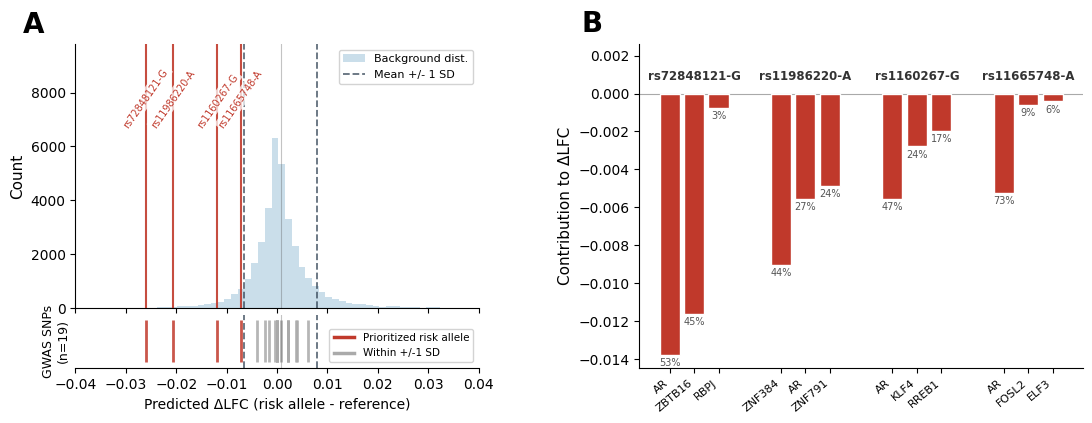

In [11]:
fig = plt.figure(figsize=(13, 4.2))
gs = gridspec.GridSpec(2, 2, figure=fig, height_ratios=[5, 1], width_ratios=[1, 1.1], hspace=0.04, wspace=0.38)
ax_hist = fig.add_subplot(gs[0, 0])
ax_rug = fig.add_subplot(gs[1, 0], sharex=ax_hist)
ax_tf = fig.add_subplot(gs[:, 1])

# -- Panel A: histogram + rug --
lo_thr, hi_thr = bg_mean - bg_std, bg_mean + bg_std
indiv_scores = snp_comprehensive['indiv_score'].values
snp_col = lambda s: '#C0392B' if s < lo_thr else ('#1A5276' if s > hi_thr else '#AAAAAA')
snp_colors = [snp_col(s) for s in indiv_scores]
rsids = snp_comprehensive['rsID'].values
alleles = snp_comprehensive['risk_allele'].values
sig_idx = [i for i, s in enumerate(indiv_scores) if abs(s - bg_mean) > bg_std]

n_counts, _, _ = ax_hist.hist(bg_700, bins=120, color='#A8C8DC', alpha=0.60, label='Background dist.')
ymax = n_counts.max()
ax_hist.axvline(bg_mean, color='#555', lw=0.8, ls='-', alpha=0.35)
ax_hist.axvline(lo_thr, color='#2C3E50', lw=1.3, ls='--', alpha=0.75, label='Mean +/- 1 SD')
ax_hist.axvline(hi_thr, color='#2C3E50', lw=1.3, ls='--', alpha=0.75)

y_base, y_step, label_ys = ymax * 1.05, ymax * 0.14, {}
for i in sig_idx:
    s, c = indiv_scores[i], snp_colors[i]
    ax_hist.axvline(s, color=c, lw=1.5, alpha=0.90, zorder=6)
    x_key = round(s * 200) / 200
    y_lbl = y_base + label_ys.get(x_key, 0) * y_step
    label_ys[x_key] = label_ys.get(x_key, 0) + 1
    ax_hist.text(s, y_lbl, f'{rsids[i]}-{alleles[i]}',
                 fontsize=7, ha='center', va='bottom', color=c, rotation=55,
                 clip_on=False, fontweight='medium', zorder=7,
                 bbox=dict(fc='white', alpha=0.75, ec='none', pad=1.5))

ax_hist.set_ylabel('Count', fontsize=11)
ax_hist.set_ylim(0, ymax * 1.55)
ax_hist.set_xlim(-0.04, 0.04)
ax_hist.legend(fontsize=8, loc='upper right', framealpha=0.85)
for sp in ('top', 'right'):
    ax_hist.spines[sp].set_visible(False)
ax_hist.tick_params(labelbottom=False)

ax_rug.vlines(indiv_scores, 0.1, 0.9, colors=snp_colors, linewidths=2.0, alpha=0.85)
ax_rug.axvline(bg_mean, color='#555', lw=0.8, ls='-', alpha=0.35)
ax_rug.axvline(lo_thr, color='#2C3E50', lw=1.3, ls='--', alpha=0.75)
ax_rug.axvline(hi_thr, color='#2C3E50', lw=1.3, ls='--', alpha=0.75)
ax_rug.set_yticks([])
ax_rug.set_ylim(0, 1)
ax_rug.set_ylabel(f'GWAS SNPs\n(n={len(snp_comprehensive)})', fontsize=9, labelpad=4)
ax_rug.set_xlabel('Predicted ΔLFC (risk allele - reference)', fontsize=10)
for sp in ('top', 'right', 'left'):
    ax_rug.spines[sp].set_visible(False)
ax_rug.legend(handles=[Line2D([0], [0], color='#C0392B', lw=2.5, label='Prioritized risk allele'),
                        Line2D([0], [0], color='#AAAAAA', lw=2.5, label='Within +/-1 SD')],
              fontsize=7.5, loc='lower right', framealpha=0.85)

# -- Panel B: TF decomposition (compact) --
bar_w, group_gap = 0.18, 0.28
x_ticks, x_labels, group_info = [], [], []
for g, snp in enumerate(df_decomp['snp_label'].unique()):
    sub = df_decomp[df_decomp['snp_label'] == snp].sort_values('rank')
    g0 = g * (3 * bar_w + group_gap)
    for j, (_, row) in enumerate(sub.iterrows()):
        x = g0 + j * bar_w
        ax_tf.bar(x, row['contrib'], width=bar_w * 0.82, color='#C0392B', edgecolor='white', zorder=3)
        ax_tf.annotate(f"{row['ratio']:.0%}", xy=(x, row['contrib']), xytext=(0, -2),
                       textcoords='offset points', ha='center', va='top', fontsize=7, color='#555')
        x_ticks.append(x)
        x_labels.append(row['tf'])
    group_info.append((g0 + bar_w, snp))
ax_tf.axhline(0, color='#555', lw=0.8, alpha=0.5)
ax_tf.set_xticks(x_ticks)
ax_tf.set_xticklabels(x_labels, rotation=40, ha='right', fontsize=8)
ax_tf.set_ylabel('Contribution to ΔLFC', fontsize=11)
for sp in ('top', 'right'):
    ax_tf.spines[sp].set_visible(False)
fig.canvas.draw()
ylo, yhi = ax_tf.get_ylim()
for gx, label in group_info:
    ax_tf.text(gx, yhi + (yhi - ylo) * 0.04, label, ha='center', va='bottom', fontsize=8.5,
               fontweight='bold', color='#333', clip_on=False)
ax_tf.set_ylim(ylo, yhi + (yhi - ylo) * 0.18)

# Panel labels
for ax, lbl in [(ax_hist, 'A'), (ax_tf, 'B')]:
    ax.text(-0.13, 1.02, lbl, transform=ax.transAxes, fontsize=20, fontweight='bold', va='bottom')

fig.savefig(f'{FIGURES_DIR}/fig6_gwas_variant_effects.pdf', bbox_inches='tight', dpi=300)
plt.show()